## 드라이브 마운트 및 경로 추가

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/ultralytics/ultralytics
%ls

/content/drive/MyDrive/ultralytics/ultralytics
assets/                      hub/               __pycache__/       solutions/  yolov8n.pt
cfg/                         __init__.py        rtdetr-l.pt        trackers/   yolov8n-seg.pt
data/                        models/            rtdetr-x.pt        utils/      yolov8s.pt
engine/                      NH01_YOLO.ipynb    runs/              wandb/
FOOD_DETECT/                 NHC014_YOLO.ipynb  runs_food_rtdetr/  yolo11n.pt
Food_Detection_RTDETR.ipynb  NHC_DETECT/        runs_food_yolo/    yolo11s.pt
Food_Detection_YOLO.ipynb    nn/                runs_HNC_yolo/     yolov8m.pt


In [ ]:
#!mkdir custom_data
# !cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/default.yaml ./NHC_DETECT/default.yaml
# !cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/models/v8/yolov8.yaml ./NHC_DETECT/custom_yolov8.yaml

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/ultralytics')
sys.path.append('/content/drive/MyDrive/ultralytics/ultralytics')  # Add the folder to sys.path

## 파일 개수 체크

In [ ]:
train_image = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/images/train'
train_label = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train'

In [ ]:
import os
file_count = len([file for file in os.listdir(train_image) if os.path.isfile(os.path.join(train_image, file))])
print(file_count)

3227


In [ ]:
label_count = len([file for file in os.listdir(train_label) if os.path.isfile(os.path.join(train_label, file))])
print(label_count)

3293


In [ ]:
from collections import defaultdict

def find_duplicate_filenames(directory_path):
    file_map = defaultdict(list)

    for root, _, files in os.walk(directory_path):
        for file in files:
            file_map[file].append(os.path.join(root, file))

    duplicates = {name: paths for name, paths in file_map.items() if len(paths) > 1}

    return duplicates

# Example usage
duplicates = find_duplicate_filenames(train_label)

if duplicates:
    print("Duplicate filenames found:")
    for name, paths in duplicates.items():
        print(f"File '{name}' found at:")
        for path in paths:
            print(f"  {path}")
else:
    print("No duplicate filenames found.")

No duplicate filenames found.


## GPU 체크

In [ ]:
import gc
import torch
import yaml

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 모델 로드

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 32.6/235.7 GB disk)


In [ ]:
from ultralytics import YOLO

In [ ]:
model1 = YOLO("yolov8n.pt") # Load a COCO-pretrained YOLOv8nano model
model2 = YOLO("yolov8s.pt")  # Load a COCO-pretrained YOLOv8small model
model3 = YOLO("yolo11n.yaml").load("yolo11n.pt") # build from YAML and transfer weights
model4 = YOLO("yolo11s.yaml").load("yolo11s.pt") # build from YAML and transfer weights
# Display model information (optional)
model4.info()

Transferred 499/499 items from pretrained weights
Transferred 499/499 items from pretrained weights
YOLO11s summary: 319 layers, 9,458,752 parameters, 9,458,736 gradients


(319, 9458752, 9458736, 0.0)

## 로거 세팅

In [ ]:
!pip install -q wandb

In [ ]:
from google.colab import userdata
wandb_api = userdata.get('WANDB_API')

import wandb
wandb.login(key=wandb_api)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

## YOLOv8 Nano Train1

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'train1',
                 id='jr3enlwu',
                 resume='allow')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train1',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train1',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model1)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.34 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, 

100%|██████████| 755k/755k [00:00<00:00, 87.0MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [06:27<00:00,  8.32it/s]


train: New cache created: /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache
albumentations: 


...

                   all        834       5353      0.949       0.88       0.92       0.65



10 epochs completed in 0.169 hours.
Optimizer stripped from runs/detect/train14/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train14/weights/best.pt, 5.7MB

Validating runs/detect/train14/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:04<00:00,  5.77it/s]

                   all        834       5353      0.937      0.873      0.934      0.673
            hyoid_bone        790        790      0.905      0.852       0.92      0.497
             neck_bone        834       3729      0.906      0.827      0.886      0.592
                  coin        834        834          1      0.942      0.995      0.932
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▆▁█▅▅▆██▇▇
metrics/mAP50-95(B),▃▁▃▆▅▆▆█▇█
metrics/precision(B),▁▁▄▅▆▆▇▇█▇
metrics/recall(B),▄▁█▃▄▃▇▆▇▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▄▄▄▃▃▂▂▁▁


In [ ]:
# Load the trained YOLO model (train1)
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train1/weights/best.pt")

In [ ]:
metrics = model.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 91.5MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/images/valid/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [01:46<00:00,  1.54it/s]


                   all       2634      11834      0.772      0.882      0.844      0.551
            hyoid_bone       2021       2021      0.753      0.867      0.836      0.493
             neck_bone       2157       9813      0.791      0.896      0.853      0.609
Speed: 0.4ms preprocess, 2.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': 0.7717672484976603,
 'metrics/recall(B)': 0.881905525114421,
 'metrics/mAP50(B)': 0.8444478826232868,
 'metrics/mAP50-95(B)': 0.5507592533459873,
 'fitness': 0.5801281162737173}

In [ ]:
print(metrics.results_dict)

{'metrics/precision(B)': 0.7717672484976603, 'metrics/recall(B)': 0.881905525114421, 'metrics/mAP50(B)': 0.8444478826232868, 'metrics/mAP50-95(B)': 0.5507592533459873, 'fitness': 0.5801281162737173}


In [ ]:
# Load a pretrained YOLO model
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train1/weights/best.pt")

# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = model("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 8.6ms
Speed: 5.2ms preprocess, 8.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 1088)


In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 2., 1., 1., 1., 0., 1.], device='cuda:0')
conf: tensor([0.9673, 0.9468, 0.9381, 0.9220, 0.9154, 0.8878, 0.8099], device='cuda:0')
data: tensor([[8.6909e+02, 6.3756e+02, 9.8358e+02, 7.6604e+02, 9.6730e-01, 1.0000e+00],
        [6.8522e+02, 2.1954e+02, 8.0288e+02, 3.4625e+02, 9.4680e-01, 2.0000e+00],
        [7.8572e+02, 5.0386e+02, 8.8928e+02, 6.2065e+02, 9.3810e-01, 1.0000e+00],
        [8.3455e+02, 5.7550e+02, 9.3561e+02, 7.0582e+02, 9.2197e-01, 1.0000e+00],
        [7.4888e+02, 4.3516e+02, 8.5975e+02, 5.5255e+02, 9.1539e-01, 1.0000e+00],
        [5.2829e+02, 5.8031e+02, 5.7180e+02, 6.4734e+02, 8.8782e-01, 0.0000e+00],
        [7.2821e+02, 3.4577e+02, 8.3319e+02, 4.8045e+02, 8.0985e-01, 1.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1920)
shape: torch.Size([7, 6])
xywh: tensor([[926.3356, 701.8005, 114.4935, 128.4760],
        [744.0505, 282.8967, 117.6577, 126.7110],
        [837.50

In [ ]:
results[0].boxes.cls

tensor([1., 2., 1., 1., 1., 0., 1.], device='cuda:0')

In [ ]:
results[0].boxes.xyxy

tensor([[869.0888, 637.5625, 983.5823, 766.0385],
        [685.2216, 219.5411, 802.8793, 346.2522],
        [785.7231, 503.8554, 889.2839, 620.6530],
        [834.5456, 575.4978, 935.6135, 705.8206],
        [748.8772, 435.1624, 859.7509, 552.5549],
        [528.2859, 580.3083, 571.7997, 647.3362],
        [728.2135, 345.7657, 833.1915, 480.4469]], device='cuda:0')

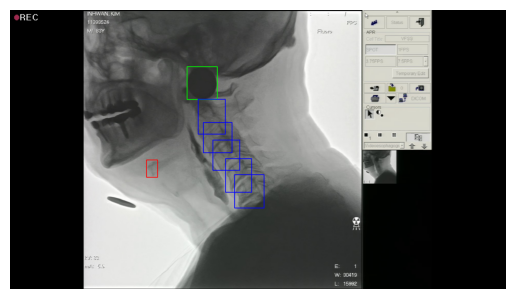

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov8_train1.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv8 Nano Train2

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'train2')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train2',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.34 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train1/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classe

100%|██████████| 755k/755k [00:00<00:00, 94.7MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]


albumentations: 


...

                   all        834       5353      0.944      0.882       0.94      0.697



40 epochs completed in 0.907 hours.
Optimizer stripped from runs/detect/train12/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/train12/weights/best.pt, 5.7MB

Validating runs/detect/train12/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:04<00:00,  6.00it/s]

                   all        834       5353      0.928      0.895      0.946      0.703
            hyoid_bone        790        790       0.94      0.904      0.962      0.561
             neck_bone        834       3729      0.846      0.824      0.883      0.606
                  coin        834        834      0.999      0.958      0.991      0.941
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▅▇▆▁▇▄▇▅▇▆▇▆█▇▇▅██▇█▆█▇▇▇▆▇██▇██▇▇▇▇█▇▇█
metrics/mAP50-95(B),▅▄▅▁▇▅▇▆▆▇▆▆▆▇▆▆█▇▇▇▅█▇▇▆▇▇▇█▇███▇▇██▇██
metrics/precision(B),▄▅▄▃▅▁▄▃▆▄▇▅▅▃█▅▇▆▅▅▂▄▅▂▄▃▅▇▂▆▆██▆█▆▆▇█▅
metrics/recall(B),▆▆▇▁▆▅▇▅▇▇▇▆█▇▇▅█▇▇▇▇▇▇▇▇▆▇▇█▇▇█▆▇▇▇▇▆▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▆▇██▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁


In [ ]:
from ultralytics import YOLO

val_model =  YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/train2/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
metrics = val_model.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 78.8MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [01:54<00:00,  1.44it/s]


                   all       2634      11834      0.758      0.912      0.822      0.556
            hyoid_bone       2021       2021       0.74      0.903       0.82      0.495
             neck_bone       2157       9813      0.776      0.921      0.823      0.617
Speed: 0.4ms preprocess, 2.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val2


{'metrics/precision(B)': 0.7582001061232972,
 'metrics/recall(B)': 0.9119261763508031,
 'metrics/mAP50(B)': 0.8218988941559693,
 'metrics/mAP50-95(B)': 0.5557375422846955,
 'fitness': 0.5823536774718229}

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = val_model.predict("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 61.2ms
Speed: 5.8ms preprocess, 61.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 1088)


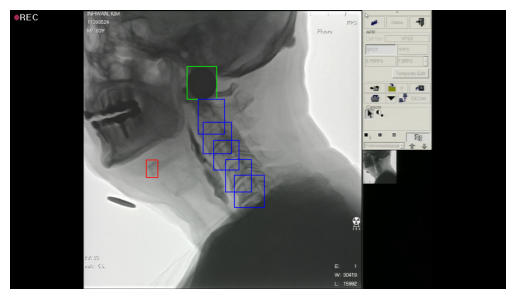

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov8_train2.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv8 Small Train3

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'train3')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='train3',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model2)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.35 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, s

100%|██████████| 755k/755k [00:00<00:00, 119MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]


albumentations: 


...

                   all        834       5353      0.943      0.909      0.956      0.718



10 epochs completed in 0.531 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 20.0MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,825 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:06<00:00,  4.14it/s]

                   all        834       5353      0.944      0.909      0.956      0.718
            hyoid_bone        790        790      0.982      0.904       0.97      0.578
             neck_bone        834       3729      0.896       0.84      0.903      0.621
                  coin        834        834      0.953      0.983      0.994      0.956
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▆▆▇▆▇▇▇██
metrics/mAP50-95(B),▁▄▄▅▆▇▆▇██
metrics/precision(B),▁▅▅▆▆▇▇▇█▇
metrics/recall(B),▁▇▇█▇███▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▅▄▄▃▃▂▂▁▁


In [ ]:
val_model3 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/train3/weights/best.pt")

In [ ]:
metrics = val_model3.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,825 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:55<00:00,  3.00it/s]


                   all       2634      11834      0.789      0.915      0.845      0.589
            hyoid_bone       2021       2021       0.78      0.903      0.849       0.54
             neck_bone       2157       9813      0.798      0.927      0.841      0.639
Speed: 0.4ms preprocess, 7.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val3


{'metrics/precision(B)': 0.7890124906660498,
 'metrics/recall(B)': 0.914975983599899,
 'metrics/mAP50(B)': 0.8449562259482968,
 'metrics/mAP50-95(B)': 0.5892550514972379,
 'fitness': 0.6148251689423438}

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = val_model3("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 67.0ms
Speed: 5.8ms preprocess, 67.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 1088)


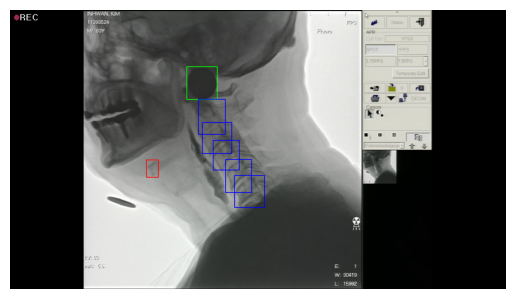

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov8_train3.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv8 Small Train4

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'train4',
                 id='6yc0h0se',
                 resume='allow')

In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='train4',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train4',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.35 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train3/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=train42, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classe

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]


albumentations: 


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/valid.cache... 834 images, 0 backgrounds, 0 corrupt: 100%|██████████| 834/834 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/images/valid/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed


...

                   all        834       5353      0.958      0.897      0.942       0.72



40 epochs completed in 1.159 hours.
Optimizer stripped from runs/detect/train42/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/train42/weights/best.pt, 20.0MB

Validating runs/detect/train42/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,825 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:06<00:00,  4.28it/s]

                   all        834       5353      0.959      0.896      0.944      0.723
            hyoid_bone        790        790       0.98      0.885      0.957      0.586
             neck_bone        834       3729        0.9      0.819      0.881      0.627
                  coin        834        834      0.998      0.984      0.995      0.954
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),█▅▇▅█▇▇▁▆▃▅▅▅█▅▇▆███▆▆██▇▇█▇▇▇▇▇▇▇▇▇▇▇▇▇
metrics/mAP50-95(B),▇▁▂▁▄▃▅▃▅▃▄▄▄▆▄▅▆▆▇▇▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████
metrics/precision(B),▇▁▅▄▆▃▅▄▆▃▅▄▆▃▅▅█▇▇▆▆▇▆▇▆▇▇▇█▇█▇▇▇▇▇▇▇▇▇
metrics/recall(B),▆▆▆▄█▆▅▁▄▂▄▃▄▇▄▅▂▆▆▇▄▃▇▇▆▅▆▆▅▅▅▆▅▆▅▆▆▆▅▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▆▇██▇▇▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁


In [ ]:
val_model4 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/train42/weights/best.pt")

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
metrics = val_model4.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,825 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:57<00:00,  2.89it/s]


                   all       2634      11834      0.796      0.894      0.814      0.579
            hyoid_bone       2021       2021      0.783       0.87      0.797      0.512
             neck_bone       2157       9813      0.809      0.917      0.831      0.645
Speed: 0.4ms preprocess, 7.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val4


{'metrics/precision(B)': 0.7958947941269912,
 'metrics/recall(B)': 0.8936540572435367,
 'metrics/mAP50(B)': 0.8142647431892986,
 'metrics/mAP50-95(B)': 0.5786513464601424,
 'fitness': 0.6022126861330581}

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO model
model = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train42/weights/best.pt")

# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = model("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 68.8ms
Speed: 7.5ms preprocess, 68.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 1088)


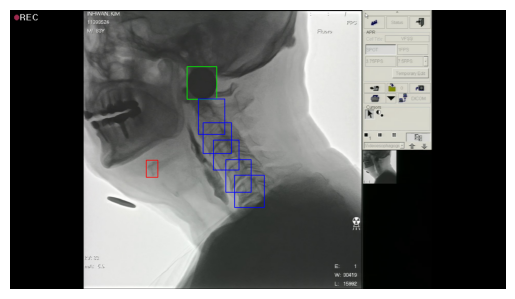

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov8_train1.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv11 Nano Train1

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'yolo11_train1')

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolo11_train1',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train5',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model3)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.35 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11_train1, exist_ok=False, pretrained=yolo11n.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]

albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/valid.cache... 834 images, 0 backgrounds, 0 corrupt: 100%|██████████| 834/834 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/images/valid/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed


...

                   all        834       5353      0.937      0.925       0.96      0.678



10 epochs completed in 0.201 hours.
Optimizer stripped from runs/detect/yolo11_train1/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/yolo11_train1/weights/best.pt, 5.5MB

Validating runs/detect/yolo11_train1/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:04<00:00,  5.86it/s]

                   all        834       5353       0.93      0.921      0.955      0.694
            hyoid_bone        790        790      0.907      0.932      0.958      0.543
             neck_bone        834       3729      0.894      0.855      0.913        0.6
                  coin        834        834      0.989      0.976      0.994      0.941
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▄▄▅▇▇▇███
metrics/mAP50-95(B),▁▄▃▄▆█▇█▇█
metrics/precision(B),▃▆▅▁▆▇▇███
metrics/recall(B),▁▂▃▅▇▇████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▅▄▄▃▃▂▂▁▁


In [ ]:
val_model5 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/yolo11_train1/weights/best.pt")
metrics = val_model5.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:46<00:00,  3.56it/s]


                   all       2634      11834      0.776      0.901      0.872      0.566
            hyoid_bone       2021       2021      0.758        0.9      0.885      0.511
             neck_bone       2157       9813      0.795      0.901      0.859       0.62
Speed: 0.4ms preprocess, 3.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val5


{'metrics/precision(B)': 0.7763842354963373,
 'metrics/recall(B)': 0.9005642023500335,
 'metrics/mAP50(B)': 0.872124697908764,
 'metrics/mAP50-95(B)': 0.5659216309168807,
 'fitness': 0.5965419376160691}

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = val_model5("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 80.8ms
Speed: 18.7ms preprocess, 80.8ms inference, 824.3ms postprocess per image at shape (1, 3, 640, 1088)


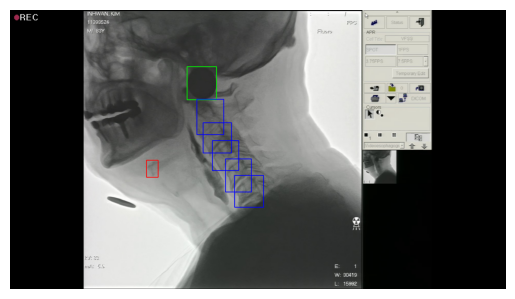

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov11_train5.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv11 Nano Train2


In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'yolo11_train2')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main():

    # Define the arguments for the trainer
    args = dict(name='yolo11_train2',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolo11_train2',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main()

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.36 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/train2/weights/best.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11_train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, 

100%|██████████| 755k/755k [00:00<00:00, 22.0MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]


albumentations: 


...

                   all        834       5353      0.932      0.886      0.943      0.693



40 epochs completed in 0.770 hours.
Optimizer stripped from runs/detect/yolo11_train2/weights/last.pt, 5.7MB
Optimizer stripped from runs/detect/yolo11_train2/weights/best.pt, 5.7MB

Validating runs/detect/yolo11_train2/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:04<00:00,  5.92it/s]

                   all        834       5353      0.933      0.886      0.943      0.696
            hyoid_bone        790        790      0.952      0.898      0.961      0.554
             neck_bone        834       3729       0.85      0.804      0.879      0.619
                  coin        834        834      0.997      0.956      0.989      0.916
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▅▆▅▆▅▇▄▄▄▅▆▅▅▄▅▅▅▆▅▆▇▇▆█▆▅█▇▇▅▇▇▇▇▇▇▇▇▇
metrics/mAP50-95(B),▁▃▆▅▆▅▇▆▆▇▇▆▆▆▅▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██▇▇█████
metrics/precision(B),▁▄▄▃▁▂▅▅▇▄▆▅▅▃█▅▂▅▆▅▅▅▆▆▆█▆▆▆▆▆▇▆▅▆▅▆▆▆▆
metrics/recall(B),▁▅▆▆▇▁▇▁▂▄▅▇▄▆▁▅▅▅▆▅▇█▆▅▇▄▃█▇▆▄▇▆▆▆▅▅▄▅▅
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁


In [ ]:
val_model6 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/yolo11_train2/weights/best.pt")
metrics = val_model6.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:46<00:00,  3.56it/s]


                   all       2634      11834      0.774       0.91      0.821       0.55
            hyoid_bone       2021       2021       0.76      0.884      0.808       0.48
             neck_bone       2157       9813      0.789      0.937      0.835       0.62
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val6


{'metrics/precision(B)': 0.7741888520555982,
 'metrics/recall(B)': 0.9102987074568298,
 'metrics/mAP50(B)': 0.8212172150524717,
 'metrics/mAP50-95(B)': 0.5504567440992059,
 'fitness': 0.5775327911945325}

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = val_model6("/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg")


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 1 coin, 10.4ms
Speed: 5.6ms preprocess, 10.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 1088)


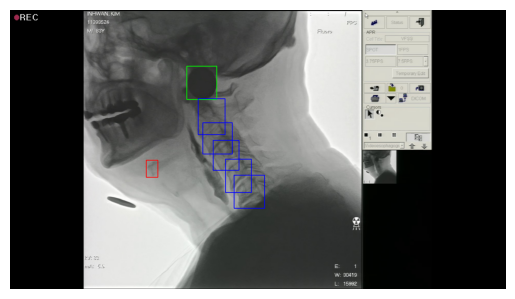

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs/predict/yolov11_train2.jpg")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

## YOLOv11 Small Train3

In [ ]:
run = wandb.init(project="NHC014_YOLO",
                 name = 'yolo11_train3')

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolo11_train3',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolo11_train3',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model4)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.40 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.yaml, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11_train3, exist_ok=False, pretrained=yolo11s.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

100%|██████████| 755k/755k [00:00<00:00, 21.5MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]


albumentations: 


...

                   all        834       5353      0.938      0.898      0.952      0.693



10 epochs completed in 0.435 hours.
Optimizer stripped from runs/detect/yolo11_train3/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolo11_train3/weights/best.pt, 19.2MB

Validating runs/detect/yolo11_train3/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:06<00:00,  4.20it/s]

                   all        834       5353      0.939      0.891      0.946      0.708
            hyoid_bone        790        790      0.974       0.85      0.953      0.573
             neck_bone        834       3729      0.882      0.823      0.891      0.607
                  coin        834        834       0.96          1      0.995      0.944
Speed: 0.3ms preprocess, 4.2ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▆▆▁▂▂▃█▇██
metrics/mAP50-95(B),▁▅▁▃▅▇▅▅██
metrics/precision(B),▁▂▄▄▄▆█▃▇▇
metrics/recall(B),▆▄▁▄▁▃█▆▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▅▅▄▃▃▂▂▁▁


In [ ]:
val_model7 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/yolo11_train3/weights/best.pt")
metrics = val_model7.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:56<00:00,  2.93it/s]


                   all       2634      11834      0.788      0.892      0.845      0.592
            hyoid_bone       2021       2021      0.779       0.86      0.832      0.534
             neck_bone       2157       9813      0.797      0.924      0.858       0.65
Speed: 0.4ms preprocess, 7.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val7


{'metrics/precision(B)': 0.7880327555301481,
 'metrics/recall(B)': 0.8917226071530542,
 'metrics/mAP50(B)': 0.8449449581350084,
 'metrics/mAP50-95(B)': 0.59162138406539,
 'fitness': 0.6169537414723519}

## YOLOv11 Small Train4

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolo11_train4',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolo11_train4',
                plots=True)

    run = wandb.init(project="NHC014_YOLO",
                     name = 'yolo11_train4',
                     config=args)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device']) # Move model to the specified device

    results = model.train(**args) # Pass args during training
    metrics = model.val()
    wandb.log({
            "val_precision": metrics.get('metrics/precision', 0),
            "val_recall": metrics.get('metrics/recall', 0),
            "val_mAP50": metrics.get('metrics/mAP50', 0),
            "val_mAP50-95": metrics.get('metrics/mAP50-95', 0),
            "train_loss": metrics.get('train/loss', 0),
            "val_loss": metrics.get('val/loss', 0)
        })

     # Finish the WandB run
    wandb.finish()

if __name__ == "__main__":
  main(model4)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.40 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.yaml, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11_train4, exist_ok=False, pretrained=yolo11s.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/train.cache... 3227 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3227/3227 [00:00<?, ?it/s]

albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/labels/valid.cache... 834 images, 0 backgrounds, 0 corrupt: 100%|██████████| 834/834 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/images/valid/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed


...


40 epochs completed in 1.263 hours.
Optimizer stripped from runs/detect/yolo11_train4/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolo11_train4/weights/best.pt, 19.2MB

Validating runs/detect/yolo11_train4/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:08<00:00,  3.04it/s]


                   all        834       5353      0.889      0.905      0.947      0.706
            hyoid_bone        790        790      0.888      0.908      0.946      0.533
             neck_bone        834       3729      0.905      0.817      0.902      0.647
                  coin        834        834      0.873       0.99      0.993      0.939
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/yolo11_train4


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▇▄▁▇▄▅▅▅▅▆▃▅▄▇█▇▇▆▇▆▆█▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇▇
metrics/mAP50-95(B),█▅▁█▆▄▅▄▆▅▄▄▄▅▅▄▆▅▆▄▅▅▅▅▄▅▅▅▅▆▅▅▅▄▅▅▅▅▅█
metrics/precision(B),▄▅▁▂▂▆▅▇▃▆▅▇▃▆█▄█▇▇▃▆▇▆▄▇▇▄▇▆▆▅▆▇▇▅▇▄▇▆▂
metrics/recall(B),▇▃▁▇▁▃▄▃▄▆▂▅▃▅▇▇▆▅▅▆▄▇▇▇▆▅▆▇▆█▆▇▄▇▆▇▇▅▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▆▇██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁


AttributeError: 'DetMetrics' object has no attribute 'get'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when the

In [ ]:
val_model8 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs_HNC_yolo/detect/yolo11_train4/weights/best.pt")
metrics = val_model8.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:32<00:00,  5.02it/s]


                   all       2634      11834      0.775      0.858      0.809      0.549
            hyoid_bone       2021       2021      0.733      0.841      0.803      0.472
             neck_bone       2157       9813      0.817      0.875      0.814      0.625
Speed: 0.4ms preprocess, 7.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val8


{'metrics/precision(B)': 0.775085008827479,
 'metrics/recall(B)': 0.8579710344004051,
 'metrics/mAP50(B)': 0.8086423530462923,
 'metrics/mAP50-95(B)': 0.5486869784784474,
 'fitness': 0.5746825159352319}